# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
pd.options.future.infer_string = False   
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### Data

In [2]:
train_transaction = pd.read_csv("../data/raw/ieee-fraud-detection/train_transaction.csv")
train_identity = pd.read_csv("../data/raw/ieee-fraud-detection/train_identity.csv")

test_transaction = pd.read_csv("../data/raw/ieee-fraud-detection/test_transaction.csv")
test_identity = pd.read_csv("../data/raw/ieee-fraud-detection/test_identity.csv")

In [3]:
common_columns = train_transaction.columns.intersection(train_identity.columns).tolist()

train = train_transaction.merge(train_identity, on=common_columns, how="left")

test = test_transaction.merge(test_identity, on=common_columns, how="left")

### Missing Value Analysis

In [4]:
missing_summary = pd.DataFrame({
    "missing_count": train.isnull().sum(),
    "missing_ratio": train.isnull().mean() * 100
    }).sort_values("missing_ratio", ascending=False)

# 20% NaN ratio threshold is used as a practical warning level. 
threshold = 20

columns_over_threshold = missing_summary[missing_summary["missing_ratio"] > threshold]

num_columns_over_threshold = columns_over_threshold.shape[0]
total_columns = train.shape[1]
ratio_columns_over_threshold = (num_columns_over_threshold / total_columns) * 100

print(f"Total number of columns: {total_columns}")
print(f"Number of columns with missing ratio > {threshold}%: {num_columns_over_threshold}")
print(f"Ratio of columns with missing ratio > {threshold}%: {ratio_columns_over_threshold:.2f}%")

# A high proportion of variables have substantial missing values, indicating a serious data quality issue before modeling.

Total number of columns: 434
Number of columns with missing ratio > 20%: 252
Ratio of columns with missing ratio > 20%: 58.06%


In [5]:
# NaNs were analyzed on the training set to check whether missing values follow a systematic pattern.
# If missing records show different target behavior, missingness may not be completely random.

# MCAR: Missing Completely At Random
# MAR: Missing At Random
# MNAR: Missing Not At Random
# Note: MNAR cannot be proven directly with this test (This analysis only checks whether missingness is related to the target).

# diff_threshold defines the minimum target rate difference used to flag missingness as potentially systematic.

def missing_pattern_analysis(df, target_col=None, threshold=0.20, diff_threshold=0.01):
    missing_summary = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_ratio": df.isnull().mean()
    }).sort_values("missing_ratio", ascending=False)

    high_missing_cols = missing_summary[missing_summary["missing_ratio"] > threshold]

    if target_col is not None:
        target_missing_relation = []

        for col in df.columns:
            if col != target_col and df[col].isnull().sum() > 0:
                missing_flag = df[col].isnull().astype(int)

                target_mean_when_missing = df.loc[missing_flag == 1, target_col].mean()
                target_mean_when_not_missing = df.loc[missing_flag == 0, target_col].mean()

                difference = target_mean_when_missing - target_mean_when_not_missing

                if abs(difference) < diff_threshold:
                    missingness_type = "Likely MCAR"
                else:
                    missingness_type = "Possibly MAR/MNAR"

                target_missing_relation.append({
                    "variable": col,
                    "missing_ratio": df[col].isnull().mean(),
                    "target_mean_when_missing": target_mean_when_missing,
                    "target_mean_when_not_missing": target_mean_when_not_missing,
                    "difference": difference,
                    "missingness_type": missingness_type})

        target_missing_relation = pd.DataFrame(target_missing_relation)
        target_missing_relation = target_missing_relation.sort_values("difference", ascending=False)

        missingness_counts = target_missing_relation["missingness_type"].value_counts()

        print("\nMissingness Type Counts:")
        print(missingness_counts)

        print("\nColumns by Missingness Type:")

        for m_type in target_missing_relation["missingness_type"].unique():
            cols = target_missing_relation.loc[
                target_missing_relation["missingness_type"] == m_type,
                "variable"].tolist()

            print(f"\n{m_type}: {len(cols)} columns")
            print(cols)

        return missing_summary, target_missing_relation

    return missing_summary

In [6]:
missing_summary, target_missing_relation = missing_pattern_analysis(train, target_col="isFraud", threshold=0.20, diff_threshold=0.01)

# Most missing variables were classified as Possibly MAR/MNAR, suggesting that missingness is likely systematic and may carry predictive information rather than being completely random.


Missingness Type Counts:
missingness_type
Possibly MAR/MNAR    379
Likely MCAR           35
Name: count, dtype: int64

Columns by Missingness Type:

Possibly MAR/MNAR: 379 columns
['V280', 'V309', 'V320', 'V304', 'V305', 'V306', 'V307', 'V308', 'V319', 'V299', 'V318', 'V317', 'V316', 'V312', 'V311', 'V310', 'V302', 'V303', 'V298', 'V297', 'V284', 'V285', 'V286', 'V279', 'V287', 'V290', 'V291', 'V292', 'V321', 'V293', 'V294', 'V295', 'addr2', 'addr1', 'M6', 'M2', 'M3', 'M1', 'V8', 'V11', 'V10', 'V9', 'V7', 'V6', 'V5', 'V4', 'V3', 'V2', 'V1', 'D11', 'V62', 'V69', 'V68', 'V67', 'V66', 'V65', 'V64', 'V63', 'V58', 'V61', 'V60', 'V59', 'V71', 'V57', 'V56', 'V55', 'V70', 'V54', 'V72', 'V74', 'V53', 'V73', 'M9', 'M8', 'M7', 'dist1', 'D2', 'V98', 'V97', 'V100', 'V99', 'V101', 'V102', 'V103', 'V104', 'V105', 'V133', 'V106', 'V107', 'V137', 'V136', 'V135', 'V134', 'V132', 'V131', 'V130', 'V129', 'V128', 'V127', 'V126', 'V125', 'V124', 'V123', 'V122', 'V121', 'V120', 'V119', 'V118', 'V117', 'V116

In [7]:
threshold = 0.2 # 20% NaN ratio threshold is used as a practical warning level.

columns_over_threshold = (missing_summary[missing_summary["missing_ratio"] > threshold].index.tolist())

columns_over_threshold = [col for col in columns_over_threshold if col != "isFraud"]

missing_flags = train[columns_over_threshold].isnull().astype("int8")

target = train["isFraud"].astype("int8")

target_corr = missing_flags.corrwith(target)

top_n = 15 # Number of variables with the strongest missingness-target correlation to display for readability.

top_missing_cols_by_target = (target_corr.abs().sort_values(ascending=False).head(top_n).index.tolist())

plot_data = missing_flags[top_missing_cols_by_target].copy()
plot_data["isFraud"] = target

plot_corr_matrix = plot_data.corr()

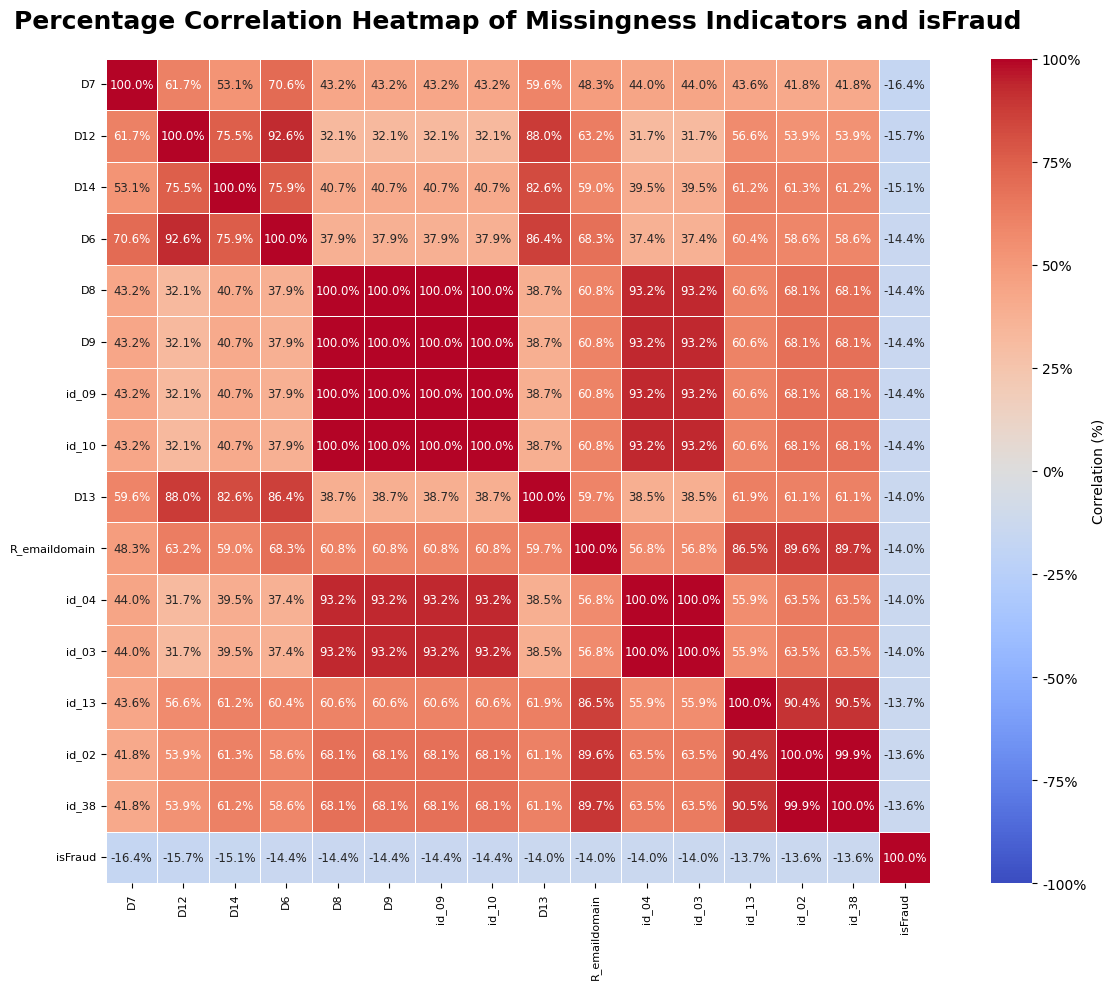

In [8]:
plot_corr_matrix_percent = plot_corr_matrix * 100

annot_labels = plot_corr_matrix_percent.round(1).astype(str) + "%"

plt.figure(figsize=(13, 10))

ax = sns.heatmap(
    plot_corr_matrix_percent,
    cmap="coolwarm",
    center=0,
    vmin=-100,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    square=True,
    annot=annot_labels,
    fmt="",
    annot_kws={"size": 8.5},
    cbar_kws={"label": "Correlation (%)"})


cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}%"))

ax.set_title(
    "Percentage Correlation Heatmap of Missingness Indicators and isFraud",
    fontsize=18,
    fontweight="bold",
    pad=22)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

#T his heatmap shows both the correlations among missingness indicators and their correlation with the target variable isFraud. 
# The isFraud row/column is the key part; stronger positive or negative values there indicate that missingness may be related to fraud behavior.

### Automatic Column Type Detection

In [9]:
column_types = []

for col in train.columns:
    unique_count = train[col].nunique(dropna=False)
    unique_ratio = unique_count / len(train)
    dtype = train[col].dtype

    if col == "isFraud":
        col_type = "target"

    elif col == "TransactionID" or unique_ratio > 0.95:
        col_type = "id_like"

    elif unique_count == 2:
        col_type = "binary"

    elif pd.api.types.is_numeric_dtype(train[col]):
        col_type = "numeric"

    elif pd.api.types.is_object_dtype(train[col]):
        if unique_ratio > 0.80:
            col_type = "high_cardinality_categorical"
        else:
            col_type = "categorical"

    else:
        col_type = "other"

    column_types.append({
        "column_name": col,
        "dtype": str(dtype),
        "unique_count": unique_count,
        "unique_ratio": round(unique_ratio * 100, 2),
        "detected_type": col_type
    })

column_type_summary = pd.DataFrame(column_types)

display(
    column_type_summary["detected_type"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "detected_type", "detected_type": "column_count"}))

,column_count,count
0,numeric,400
1,categorical,31
2,id_like,2
3,target,1


### Data Quality Analysis

In [10]:
total_rows, total_columns = train.shape
total_cells = total_rows * total_columns

missing_values = train.isnull().sum()
total_missing_values = missing_values.sum()
missing_ratio = total_missing_values / total_cells * 100

columns_with_missing = (missing_values > 0).sum()
columns_with_missing_ratio = columns_with_missing / total_columns * 100

complete_columns = (missing_values == 0).sum()
complete_columns_ratio = complete_columns / total_columns * 100

empty_columns = (missing_values == total_rows).sum()
empty_columns_ratio = empty_columns / total_columns * 100

duplicate_rows = train.duplicated().sum()
duplicate_ratio = duplicate_rows / total_rows * 100

constant_columns = (train.nunique(dropna=False) == 1).sum()
constant_columns_ratio = constant_columns / total_columns * 100

print("Dataset Shape")
print(f"Total rows: {total_rows}")
print(f"Total columns: {total_columns}")
print(f"Total cells: {total_cells}")

print("\nMissing Value Quality")
print(f"Total missing values: {total_missing_values} ({missing_ratio:.2f}% of all cells)")
print(f"Columns with missing values: {columns_with_missing} ({columns_with_missing_ratio:.2f}% of columns)")
print(f"Complete columns: {complete_columns} ({complete_columns_ratio:.2f}% of columns)")
print(f"Completely empty columns: {empty_columns} ({empty_columns_ratio:.2f}% of columns)")

print("\nDuplicate Quality")
print(f"Duplicate rows: {duplicate_rows} ({duplicate_ratio:.2f}% of rows)")

print("\nColumn Consistency Quality")
print(f"Constant columns: {constant_columns} ({constant_columns_ratio:.2f}% of columns)")

Dataset Shape
Total rows: 590540
Total columns: 434
Total cells: 256294360

Missing Value Quality
Total missing values: 115523073 (45.07% of all cells)
Columns with missing values: 414 (95.39% of columns)
Complete columns: 20 (4.61% of columns)
Completely empty columns: 0 (0.00% of columns)

Duplicate Quality
Duplicate rows: 0 (0.00% of rows)

Column Consistency Quality
Constant columns: 0 (0.00% of columns)


In [11]:
# Missing Value Analysis by Data Type

dtype_missing_summary = pd.DataFrame({
    "data_type": train.dtypes.astype(str),
    "missing_count": train.isnull().sum(),
    "missing_ratio": train.isnull().mean() * 100})

dtype_missing_summary = (
    dtype_missing_summary
    .groupby("data_type")
    .agg(
        column_count=("data_type", "count"),
        total_missing_values=("missing_count", "sum"),
        average_missing_ratio=("missing_ratio", "mean"),
        max_missing_ratio=("missing_ratio", "max"))
    .round(2)
    .sort_values("average_missing_ratio", ascending=False))

dtype_missing_summary

,column_count,total_missing_values,average_missing_ratio,max_missing_ratio
data_type,,,,
object,31,11344179,61.97,99.12
float64,399,104178894,44.21,99.20
int64,4,0,0.00,0.00


### Column Distribution Analysis

In [12]:
numeric_cols = train.select_dtypes(include=["number"]).columns
categorical_cols = train.select_dtypes(include=["object", "category", "bool"]).columns

print("Column Distribution Summary")
print(f"Total numeric columns: {len(numeric_cols)}")
print(f"Total categorical columns: {len(categorical_cols)}")

numeric_distribution = train[numeric_cols].describe().T

numeric_distribution["missing_ratio"] = train[numeric_cols].isnull().mean() * 100
numeric_distribution["zero_ratio"] = (train[numeric_cols] == 0).mean() * 100
numeric_distribution["unique_count"] = train[numeric_cols].nunique()

numeric_distribution = numeric_distribution.round()

numeric_distribution.head(10)

Column Distribution Summary
Total numeric columns: 403
Total categorical columns: 31


,count,mean,std,min,25%,50%,75%,max,missing_ratio,zero_ratio,unique_count
TransactionID,590540.0,3282270.0,170474.0,2987000.0,3134635.0,3282270.0,3429904.0,3577539.0,0.0,0.0,590540
isFraud,590540.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,97.0,2
TransactionDT,590540.0,7372311.0,4617224.0,86400.0,3027058.0,7306528.0,11246620.0,15811131.0,0.0,0.0,573349
TransactionAmt,590540.0,135.0,239.0,0.0,43.0,69.0,125.0,31937.0,0.0,0.0,20902
card1,590540.0,9899.0,4901.0,1000.0,6019.0,9678.0,14184.0,18396.0,0.0,0.0,13553
card2,581607.0,363.0,158.0,100.0,214.0,361.0,512.0,600.0,2.0,0.0,500
card3,588975.0,153.0,11.0,100.0,150.0,150.0,150.0,231.0,0.0,0.0,114
card5,586281.0,199.0,41.0,100.0,166.0,226.0,226.0,237.0,1.0,0.0,119
addr1,524834.0,291.0,102.0,100.0,204.0,299.0,330.0,540.0,11.0,0.0,332
addr2,524834.0,87.0,3.0,10.0,87.0,87.0,87.0,102.0,11.0,0.0,74


In [13]:
high_zero_columns = numeric_distribution.sort_values("zero_ratio", ascending=False)   # Columns with high zero ratio

high_zero_columns.head(10)

,count,mean,std,min,25%,50%,75%,max,missing_ratio,zero_ratio,unique_count
C3,590540.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,0.0,100.0,27
isFraud,590540.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,97.0,2
V286,590528.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,97.0,9
V311,590528.0,4.0,102.0,0.0,0.0,0.0,0.0,55125.0,0.0,97.0,3098
V301,589271.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,96.0,14
V300,589271.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,96.0,12
V319,590528.0,18.0,332.0,0.0,0.0,0.0,0.0,104060.0,0.0,95.0,4799
V104,590226.0,0.0,1.0,0.0,0.0,0.0,0.0,15.0,0.0,95.0,16
V106,590226.0,0.0,2.0,0.0,0.0,0.0,0.0,55.0,0.0,95.0,56
V98,590226.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,95.0,13


In [14]:
categorical_distribution = pd.DataFrame({
    "column_name": categorical_cols,
    "unique_count": train[categorical_cols].nunique().values,
    "missing_ratio": (train[categorical_cols].isnull().mean() * 100).round(2).values})

categorical_distribution.head(10)

,column_name,unique_count,missing_ratio
0,ProductCD,5,0.00
1,card4,4,0.27
2,card6,4,0.27
3,P_emaildomain,59,15.99
4,R_emaildomain,60,76.75
5,M1,2,45.91
6,M2,2,45.91
7,M3,2,45.91
8,M4,3,47.66
9,M5,2,59.35


In [17]:
def categorical_distribution_analysis(df, categorical_cols):
    records = []

    n_rows = len(df)

    for col in categorical_cols:
        series = df[col].astype("object")

        missing_ratio = series.isna().mean()
        unique_count = series.nunique(dropna=False)
        unique_ratio = unique_count / n_rows

        value_counts = series.value_counts(dropna=False, normalize=True)

        top_category = value_counts.index[0] if len(value_counts) > 0 else None
        top_category_ratio = value_counts.iloc[0] if len(value_counts) > 0 else np.nan

        rare_category_count = (series.value_counts(dropna=False) < 10).sum()

        records.append({
            "column_name": col,
            "missing_ratio": round(missing_ratio * 100, 2),
            "unique_count": unique_count,
            "unique_ratio": round(unique_ratio * 100, 2),
            "top_category_ratio": round(top_category_ratio * 100, 2),
            "rare_category_count": rare_category_count
        })

    categorical_summary = pd.DataFrame(records)

    return categorical_summary


categorical_distribution_summary = categorical_distribution_analysis(
    train,
    categorical_cols=categorical_cols)

display(
    categorical_distribution_summary
    .sort_values("unique_ratio", ascending=False)
    .head(10))

,column_name,missing_ratio,unique_count,unique_ratio,top_category_ratio,rare_category_count
30,DeviceInfo,79.91,1787,0.30,79.91,1273
23,id_33,87.59,261,0.04,87.59,181
22,id_31,76.25,131,0.02,76.25,28
3,P_emaildomain,15.99,60,0.01,38.67,0
4,R_emaildomain,76.75,61,0.01,76.75,2
21,id_30,86.87,76,0.01,86.87,4
17,id_23,99.12,4,0.00,99.12,0
29,DeviceType,76.16,3,0.00,76.16,0
28,id_38,76.13,3,0.00,76.13,0
27,id_37,76.13,3,0.00,76.13,0


### High Cardinality Field Detection

In [16]:
low_threshold = 0.10           # Columns with unique value ratio lower than 10% are considered low-cardinality fields
high_threshold = 0.80          # Columns with unique value ratio greater than 80% are considered high-cardinality fields
continuous_unique_threshold = 50            
id_like_columns = {"TransactionID", "TransactionDT"}

unique_counts = train.nunique(dropna=False)
unique_ratios = unique_counts / len(train)

cardinality_summary = pd.DataFrame({
    "column_name": train.columns,
    "data_type": train.dtypes.astype(str).values,
    "unique_count": unique_counts.values,
    "unique_ratio": unique_ratios.values})

cardinality_summary["unique_ratio_percent"] = (cardinality_summary["unique_ratio"] * 100).round(2)
cardinality_summary["is_numeric"] = train.dtypes.apply(lambda dtype: pd.api.types.is_numeric_dtype(dtype)).values
cardinality_summary["is_categorical"] = train.dtypes.apply(
    lambda dtype: pd.api.types.is_object_dtype(dtype)
    or pd.api.types.is_string_dtype(dtype)
    or pd.api.types.is_categorical_dtype(dtype)
    or pd.api.types.is_bool_dtype(dtype)).values

cardinality_summary["is_id_like"] = cardinality_summary["column_name"].isin(id_like_columns)

cardinality_summary["cardinality_level"] = pd.cut(
    cardinality_summary["unique_ratio"],
    bins=[-0.01, low_threshold, high_threshold, 1.00],
    labels=["Low Cardinality", "Medium Cardinality", "High Cardinality"])

cardinality_summary["column_group"] = "low_or_medium_cardinality"
cardinality_summary.loc[
    cardinality_summary["is_id_like"],
    "column_group"] = "id_like_high_cardinality"
cardinality_summary.loc[
    (~cardinality_summary["is_id_like"])
    & cardinality_summary["is_categorical"]
    & (cardinality_summary["unique_ratio"] >= low_threshold),
    "column_group"] = "categorical_high_cardinality"
cardinality_summary.loc[
    (~cardinality_summary["is_id_like"])
    & cardinality_summary["is_numeric"]
    & (cardinality_summary["unique_count"] >= continuous_unique_threshold),
    "column_group"] = "numeric_continuous"     # numeric_continuous: numeric columns with many unique values

column_group_counts = cardinality_summary["column_group"].value_counts().reset_index()
column_group_counts.columns = ["column_group", "column_count"]

print("Group Summary:")
print(column_group_counts)

cardinality_summary.sort_values(["column_group", "unique_ratio_percent"], ascending=[True, False])

Group Summary:
                column_group  column_count
0  low_or_medium_cardinality           236
1         numeric_continuous           196
2   id_like_high_cardinality             2


,column_name,data_type,unique_count,unique_ratio,unique_ratio_percent,is_numeric,is_categorical,is_id_like,cardinality_level,column_group
0,TransactionID,int64,590540,1.000000,100.00,True,False,True,High Cardinality,id_like_high_cardinality
2,TransactionDT,int64,573349,0.970889,97.09,True,False,True,High Cardinality,id_like_high_cardinality
433,DeviceInfo,object,1787,0.003026,0.30,False,True,False,Low Cardinality,low_or_medium_cardinality
426,id_33,object,261,0.000442,0.04,False,True,False,Low Cardinality,low_or_medium_cardinality
424,id_31,object,131,0.000222,0.02,False,True,False,Low Cardinality,low_or_medium_cardinality
...,...,...,...,...,...,...,...,...,...,...
384,V330,float64,57,0.000097,0.01,True,False,False,Low Cardinality,numeric_continuous
394,id_01,float64,78,0.000132,0.01,True,False,False,Low Cardinality,numeric_continuous
400,id_07,float64,85,0.000144,0.01,True,False,False,Low Cardinality,numeric_continuous
403,id_10,float64,63,0.000107,0.01,True,False,False,Low Cardinality,numeric_continuous


## Summary of Findings

The dataset has a high dimensional structure and includes several data quality challenges. Missing values are a major issue, and some variables show sparse or highly unique value patterns. These findings indicate that careful preprocessing, feature selection, and appropriate missing value handling are necessary before anomaly detection and modeling.